In [1]:
import os
os.chdir('..')
print(os.getcwd())

c:\Users\User\bangla-emotion-classifier


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score
)

print("All imports successful")

C:\Users\User\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


All imports successful


In [3]:
# Load the cleaned data we saved in Phase 2
# No cleaning needed — it's already done
train_df = pd.read_csv('data/processed/train.csv')
val_df   = pd.read_csv('data/processed/val.csv')
test_df  = pd.read_csv('data/processed/test.csv')

# Load class weights
with open('data/processed/class_weights.json', 'r') as f:
    class_weights = json.load(f)

print(f"Train : {len(train_df)} rows")
print(f"Val   : {len(val_df)} rows")
print(f"Test  : {len(test_df)} rows")
print(f"Class weights: {class_weights}")

Train : 14124 rows
Val   : 1741 rows
Test  : 1775 rows
Class weights: {'anger': 1.635479388605836, 'fear': 1.8229220443985545, 'joy': 0.6585229392017904, 'sadness': 0.7567509644234891}


In [4]:
# X = input features (the text)
# y = output labels (the emotion)
# This naming convention is universal in ML — always use it

X_train = train_df['clean_text']
X_val   = val_df['clean_text']
X_test  = test_df['clean_text']

y_train = train_df['emotion']
y_val   = val_df['emotion']
y_test  = test_df['emotion']

print("--- Feature shapes ---")
print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")

print("\n--- Label distribution (train) ---")
print(y_train.value_counts())

--- Feature shapes ---
X_train : (14124,)
X_val   : (1741,)
X_test  : (1775,)

--- Label distribution (train) ---
emotion
joy        5362
sadness    4666
anger      2159
fear       1937
Name: count, dtype: int64


In [5]:
# Build TF-IDF vectorizer
vectorizer = TfidfVectorizer(
    max_features=10000,   # Keep top 10,000 words by TF-IDF score
    ngram_range=(1, 2),   # Use both unigrams and bigrams
    min_df=2,             # Ignore words appearing in < 2 documents
    sublinear_tf=True     # Apply log normalization to term frequency
                          # so "happy happy happy" doesn't dominate
)

# CRITICAL: fit ONLY on training data
# Never fit on val or test — that would be data leakage
X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf   = vectorizer.transform(X_val)
X_test_tfidf  = vectorizer.transform(X_test)

print("--- TF-IDF Matrix shapes ---")
print(f"X_train_tfidf : {X_train_tfidf.shape}")
print(f"X_val_tfidf   : {X_val_tfidf.shape}")
print(f"X_test_tfidf  : {X_test_tfidf.shape}")

print(f"\nVocabulary size : {len(vectorizer.vocabulary_)}")

print("\n--- Sample features (first 20 tokens) ---")
feature_names = vectorizer.get_feature_names_out()
print(feature_names[:20].tolist())

--- TF-IDF Matrix shapes ---
X_train_tfidf : (14124, 10000)
X_val_tfidf   : (1741, 10000)
X_test_tfidf  : (1775, 10000)

Vocabulary size : 10000

--- Sample features (first 20 tokens) ---
['abandoned', 'abc', 'abdomen', 'abilities', 'ability', 'ability to', 'abit', 'able', 'able to', 'about', 'about all', 'about and', 'about anything', 'about as', 'about because', 'about being', 'about but', 'about certain', 'about doing', 'about even']


In [6]:
# Train Logistic Regression with class weights
lr_model = LogisticRegression(
    class_weight=class_weights,  # Our precomputed weights from Phase 2
    max_iter=1000,               # Maximum optimization steps
                                 # Default 100 sometimes doesn't converge
    random_state=42,             # Reproducibility — same result every run
    C=1.0                        # Regularization strength
                                 # Higher C = less regularization
                                 # Lower C = more regularization (simpler model)
)

lr_model.fit(X_train_tfidf, y_train)

# Evaluate on validation set
val_preds = lr_model.predict(X_val_tfidf)

print("--- Logistic Regression — Validation Results ---")
print(f"Accuracy : {accuracy_score(y_val, val_preds):.4f}")
print(f"F1 Macro : {f1_score(y_val, val_preds, average='macro'):.4f}")
print()
print("--- Per-class F1 scores ---")
print(classification_report(y_val, val_preds,
                            target_names=['anger','fear','joy','sadness']))

--- Logistic Regression — Validation Results ---
Accuracy : 0.9173
F1 Macro : 0.9056

--- Per-class F1 scores ---
              precision    recall  f1-score   support

       anger       0.88      0.89      0.89       275
        fear       0.87      0.89      0.88       212
         joy       0.94      0.95      0.94       704
     sadness       0.93      0.90      0.91       550

    accuracy                           0.92      1741
   macro avg       0.90      0.91      0.91      1741
weighted avg       0.92      0.92      0.92      1741



In [7]:
# Naive Bayes works differently from Logistic Regression
# It uses probability theory — Bayes theorem
# "Given this word distribution, what emotion is most probable?"
# 
# Important: MultinomialNB doesn't support class_weight directly
# We pass sample_weight during fit instead

from sklearn.utils.class_weight import compute_sample_weight

# Convert class weights to sample weights
# Each sample gets the weight of its class
sample_weights = compute_sample_weight(
    class_weight=class_weights,
    y=y_train
)

nb_model = MultinomialNB(alpha=0.1)
# alpha = smoothing parameter
# Prevents zero probability for unseen words
# Lower alpha = less smoothing = more aggressive predictions

nb_model.fit(X_train_tfidf, y_train,
             sample_weight=sample_weights)

# Evaluate on validation set
nb_preds = nb_model.predict(X_val_tfidf)

print("--- Naive Bayes — Validation Results ---")
print(f"Accuracy : {accuracy_score(y_val, nb_preds):.4f}")
print(f"F1 Macro : {f1_score(y_val, nb_preds, average='macro'):.4f}")
print()
print("--- Per-class F1 scores ---")
print(classification_report(y_val, nb_preds,
                            target_names=['anger','fear','joy','sadness']))

--- Naive Bayes — Validation Results ---
Accuracy : 0.8633
F1 Macro : 0.8352

--- Per-class F1 scores ---
              precision    recall  f1-score   support

       anger       0.79      0.79      0.79       275
        fear       0.73      0.79      0.76       212
         joy       0.91      0.91      0.91       704
     sadness       0.90      0.87      0.88       550

    accuracy                           0.86      1741
   macro avg       0.83      0.84      0.84      1741
weighted avg       0.87      0.86      0.86      1741



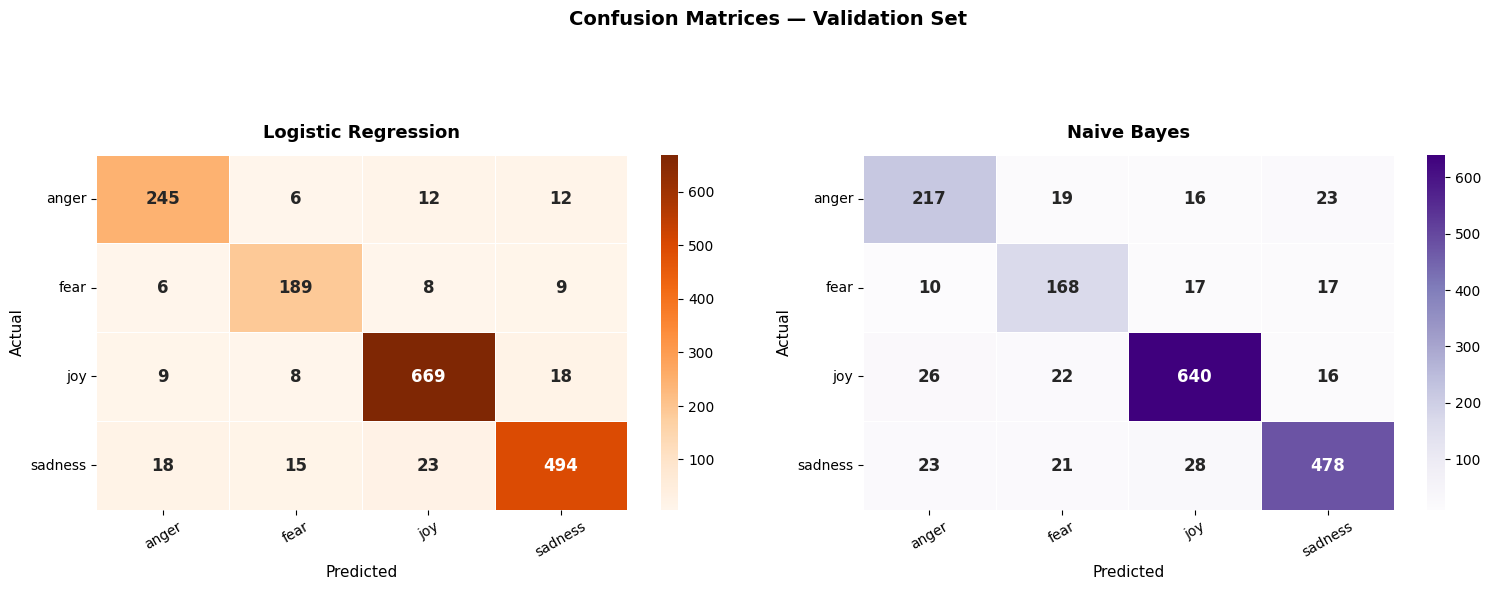

Saved to data/processed/confusion_matrices.png


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

emotions = ['anger', 'fear', 'joy', 'sadness']
cmaps    = ['Oranges', 'Purples']
titles   = ['Logistic Regression', 'Naive Bayes']
preds    = [val_preds, nb_preds]

for ax, pred, title, cmap in zip(axes, preds, titles, cmaps):
    cm = confusion_matrix(y_val, pred, labels=emotions)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=cmap,
        xticklabels=emotions,
        yticklabels=emotions,
        ax=ax,
        linewidths=0.5,
        linecolor='white',
        annot_kws={"size": 12, "weight": "bold"}
    )
    ax.set_title(f'{title}', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Predicted', fontsize=11)
    ax.set_ylabel('Actual', fontsize=11)
    ax.tick_params(axis='x', rotation=30)
    ax.tick_params(axis='y', rotation=0)

plt.suptitle('Confusion Matrices — Validation Set', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(pad=3.0)  # pad=3.0 adds space between the two charts
plt.savefig('data/processed/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to data/processed/confusion_matrices.png")

In [10]:
# Logistic Regression is our best classical model
# Now we evaluate it on the test set — first and only time

test_preds = lr_model.predict(X_test_tfidf)

print("=" * 55)
print("  FINAL TEST SET RESULTS — Logistic Regression")
print("=" * 55)
print(f"\n  Accuracy : {accuracy_score(y_test, test_preds):.4f}")
print(f"  F1 Macro : {f1_score(y_test, test_preds, average='macro'):.4f}")
print()
print(classification_report(y_test, test_preds,
                            target_names=['anger','fear','joy','sadness']))

# Save results for comparison with BanglaBERT in Phase 4
results = {
    'model'    : 'TF-IDF + Logistic Regression',
    'accuracy' : round(accuracy_score(y_test, test_preds), 4),
    'f1_macro' : round(f1_score(y_test, test_preds, average='macro'), 4),
    'per_class': {
        emotion: round(f1_score(y_test, test_preds,
                                labels=[emotion], average='macro'), 4)
        for emotion in ['anger', 'fear', 'joy', 'sadness']
    }
}

import json
with open('data/processed/baseline_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print("Saved to data/processed/baseline_results.json")

  FINAL TEST SET RESULTS — Logistic Regression

  Accuracy : 0.9234
  F1 Macro : 0.9111

              precision    recall  f1-score   support

       anger       0.87      0.89      0.88       275
        fear       0.89      0.89      0.89       224
         joy       0.94      0.97      0.96       695
     sadness       0.94      0.90      0.92       581

    accuracy                           0.92      1775
   macro avg       0.91      0.91      0.91      1775
weighted avg       0.92      0.92      0.92      1775

Saved to data/processed/baseline_results.json


In [11]:
print("""
╔══════════════════════════════════════════════════════════╗
║         PHASE 3 SUMMARY — CLASSICAL ML BASELINE         ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Models trained                                          ║
║    ✓ TF-IDF + Logistic Regression                        ║
║    ✓ TF-IDF + Naive Bayes                                ║
║                                                          ║
║  Validation results                                      ║
║    Logistic Regression : Acc 91.7%  F1 90.6%  ← winner  ║
║    Naive Bayes         : Acc 86.3%  F1 83.5%             ║
║                                                          ║
║  Final test results (Logistic Regression)                ║
║    Accuracy  : 92.3%                                     ║
║    F1 Macro  : 91.1%                                     ║
║                                                          ║
║  Per class F1 (test)                                     ║
║    joy     : 0.96  ██████████████████████████            ║
║    sadness : 0.92  ██████████████████████                ║
║    fear    : 0.89  █████████████████████                 ║
║    anger   : 0.88  ████████████████████                  ║
║                                                          ║
║  Key findings                                            ║
║    ✗ Minority classes (anger, fear) still weakest        ║
║    ✗ Sadness ↔ joy confusion most common error           ║
║    ✗ No context understanding — treats words             ║
║      independently                                       ║
║                                                          ║
║  Benchmark for Phase 4                                   ║
║    BanglaBERT must beat F1 Macro 91.1% to justify        ║
║    the added complexity of LLM fine-tuning               ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║         PHASE 3 SUMMARY — CLASSICAL ML BASELINE         ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  Models trained                                          ║
║    ✓ TF-IDF + Logistic Regression                        ║
║    ✓ TF-IDF + Naive Bayes                                ║
║                                                          ║
║  Validation results                                      ║
║    Logistic Regression : Acc 91.7%  F1 90.6%  ← winner  ║
║    Naive Bayes         : Acc 86.3%  F1 83.5%             ║
║                                                          ║
║  Final test results (Logistic Regression)                ║
║    Accuracy  : 92.3%                                     ║
║    F1 Macro  : 91.1%                                     ║
║                                                          ║
║  Per class F1 (test)   